In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
import kagglehub

path = kagglehub.dataset_download("princelv84/dogsvscats")

print(path)

C:\Users\nigel\.cache\kagglehub\datasets\princelv84\dogsvscats\versions\1


In [4]:
train_dir = os.path.join(path, 'train')

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

## Data Preprocessing

We:

-Rescale pixels (0–255 → 0–1)

-Split into training + validation

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


## Building CNN Model


Conv → detect features

Pool → reduce size

Dense → decision making

In [7]:
model = models.Sequential()

model.add(layers.Input(shape=(128, 128, 3)))

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten + Dense
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output
model.add(layers.Dense(1, activation='sigmoid'))

## Compiling Model

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training Model

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 376s 743ms/step - accuracy: 0.5799 - loss: 0.6727 - val_accuracy: 0.6740 - val_loss: 0.6144
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 295ms/step - accuracy: 0.7253 - loss: 0.5475 - val_accuracy: 0.7638 - val_loss: 0.4852
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 275ms/step - accuracy: 0.7879 - loss: 0.4557 - val_accuracy: 0.7893 - val_loss: 0.4403
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.8224 - loss: 0.3963 - val_accuracy: 0.8192 - val_loss: 0.4065
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 271ms/step - accuracy: 0.8547 - loss: 0.3325 - val_accuracy: 0.8260 - val_loss: 0.3844
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.8791 - loss: 0.2837 - val_accuracy: 0.8365 - val_loss: 0.3883
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 271ms/step - accuracy: 0.9064 - loss: 0.2230 - val_accuracy: 0.8465 - val_loss: 0.4285
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9312 -

## Plotting Accuracy & Loss

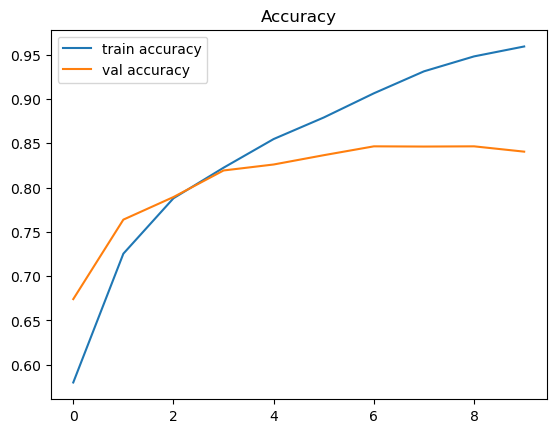

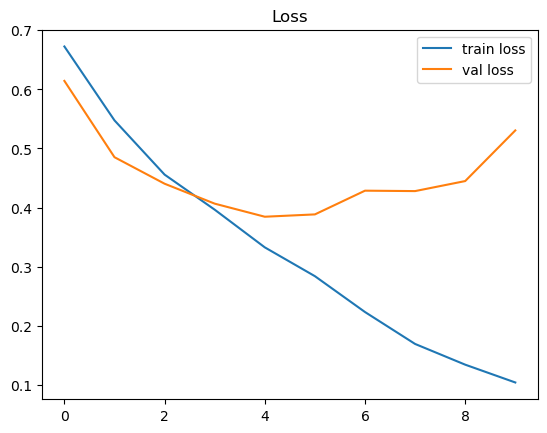

In [10]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

## Evaluating Model

In [11]:
val_data.reset()
preds = model.predict(val_data)
pred_labels = (preds > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step


## Confusion Matrix

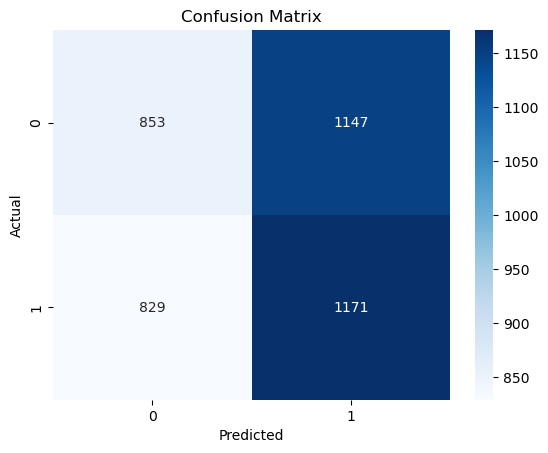

In [12]:
true_labels = val_data.classes

cm = confusion_matrix(true_labels, pred_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [13]:
print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.51      0.43      0.46      2000
           1       0.51      0.59      0.54      2000

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.50      4000
weighted avg       0.51      0.51      0.50      4000



## Visualize Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


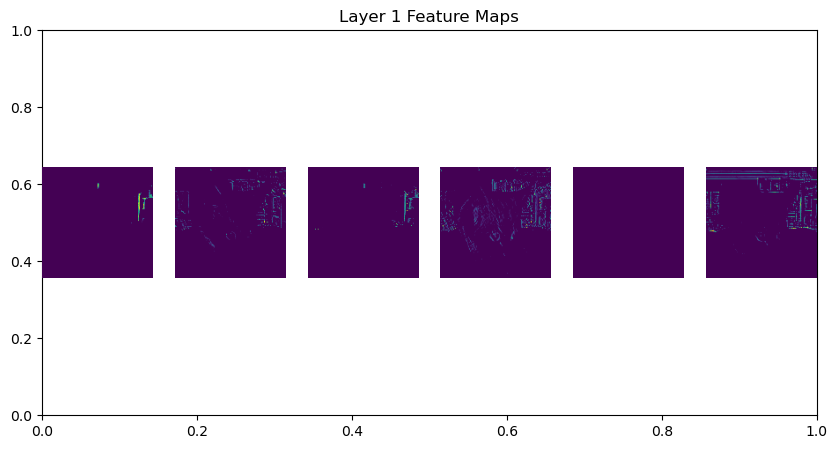

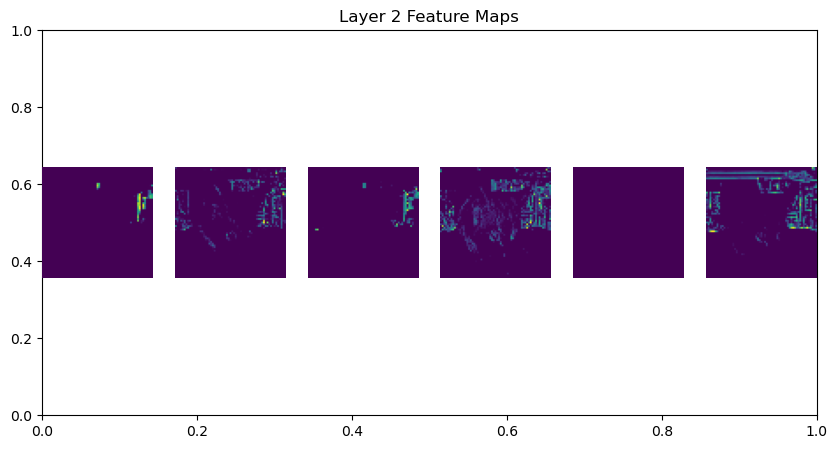

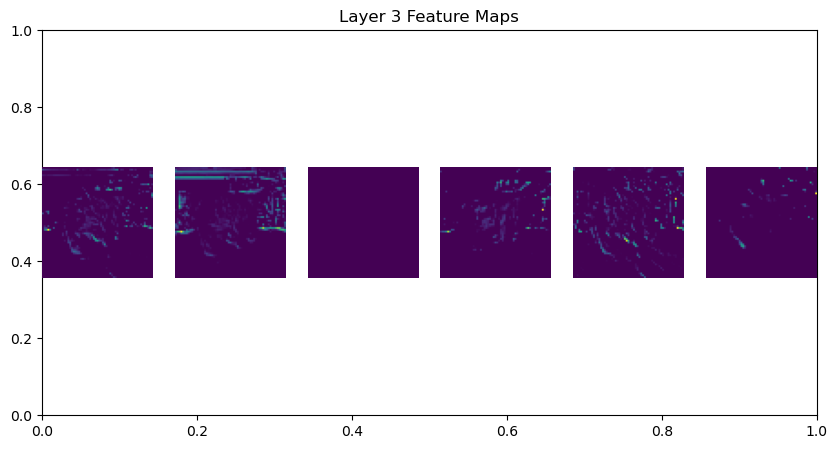

In [17]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers[:3]]
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

sample_img, _ = next(train_data)
activations = activation_model.predict(sample_img[:1])

for i, activation in enumerate(activations):
    plt.figure(figsize=(10,5))
    plt.title(f"Layer {i+1} Feature Maps")
    for j in range(min(6, activation.shape[-1])):
        plt.subplot(1,6,j+1)
        plt.imshow(activation[0,:,:,j], cmap='viridis')
        plt.axis('off')
    plt.show()